# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [2]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [3]:
# Load cleaned dataset
df = pd.read_csv("AviationData_Cleaned.csv")

# Inspect dataframe
df.head()

# Basic info
df.info()

# Summary statistics
df.describe()

C:\Users\PC\AppData\Local\Temp\ipykernel_12620\17714313.py:2: DtypeWarning: Columns (6,7,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("AviationData_Cleaned.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70452 entries, 0 to 70451
Data columns (total 34 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                70452 non-null  object 
 1   Investigation.Type      70452 non-null  object 
 2   Accident.Number         70452 non-null  object 
 3   Event.Date              70452 non-null  object 
 4   Location                70407 non-null  object 
 5   Country                 70258 non-null  object 
 6   Latitude                25954 non-null  object 
 7   Longitude               25949 non-null  object 
 8   Airport.Code            39809 non-null  object 
 9   Airport.Name            41660 non-null  object 
 10  Injury.Severity         69572 non-null  object 
 11  Aircraft.damage         67771 non-null  object 
 12  Aircraft.Category       21533 non-null  object 
 13  Registration.Number     69360 non-null  object 
 14  Make                    70452 non-null

,Number.of.Engines,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Total.Passengers,Fatality.Rate,Serious.Rate,Aircraft.Destroyed
count,65631.000000,70452.000000,70452.000000,70452.000000,70452.000000,70452.000000,69347.000000,69347.000000,70452.000000
mean,1.166659,0.586853,0.241427,0.316627,5.808621,6.953529,0.172110,0.096699,0.202578
std,0.460327,5.458084,1.566370,1.789342,29.734140,30.594072,0.366313,0.268037,0.401923
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,0.000000,0.000000,2.000000,3.000000,0.000000,0.000000,0.000000
max,8.000000,349.000000,161.000000,200.000000,699.000000,699.000000,1.000000,1.000000,1.000000


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [5]:
# Create combined injury fraction
df['Serious.Fatal.Fraction'] = (
    df['Total.Fatal.Injuries'] + df['Total.Serious.Injuries']
) / df['Total.Passengers']

# Separate small vs large aircraft
small_planes = df[df['Total.Passengers'] < 20]
large_planes = df[df['Total.Passengers'] >= 20]

# Inspect sizes
print("Small aircraft accidents:", len(small_planes))
print("Large aircraft accidents:", len(large_planes))

Small aircraft accidents: 67889
Large aircraft accidents: 2563


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

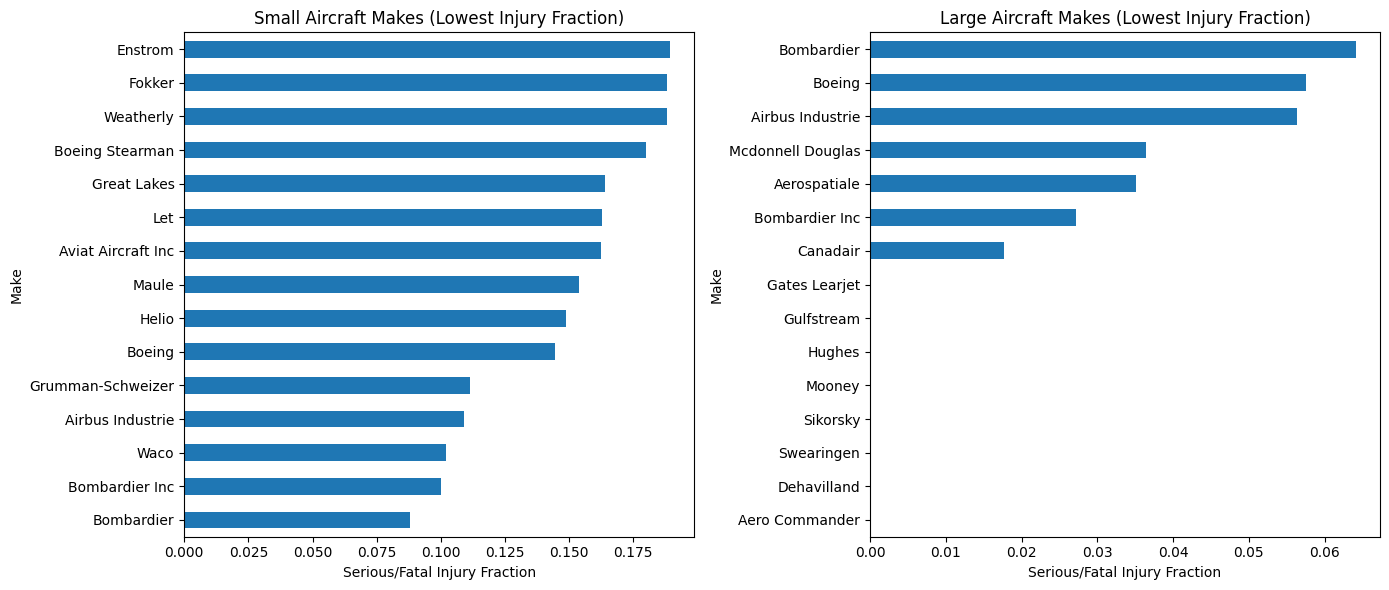

In [6]:
# Mean injury fraction by make
small_make_stats = small_planes.groupby('Make')['Serious.Fatal.Fraction'].mean().sort_values().head(15)
large_make_stats = large_planes.groupby('Make')['Serious.Fatal.Fraction'].mean().sort_values().head(15)

# Plot side by side
fig, axes = plt.subplots(1,2, figsize=(14,6))

small_make_stats.plot(kind='barh', ax=axes[0])
axes[0].set_title("Small Aircraft Makes (Lowest Injury Fraction)")
axes[0].set_xlabel("Serious/Fatal Injury Fraction")

large_make_stats.plot(kind='barh', ax=axes[1])
axes[1].set_title("Large Aircraft Makes (Lowest Injury Fraction)")
axes[1].set_xlabel("Serious/Fatal Injury Fraction")

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

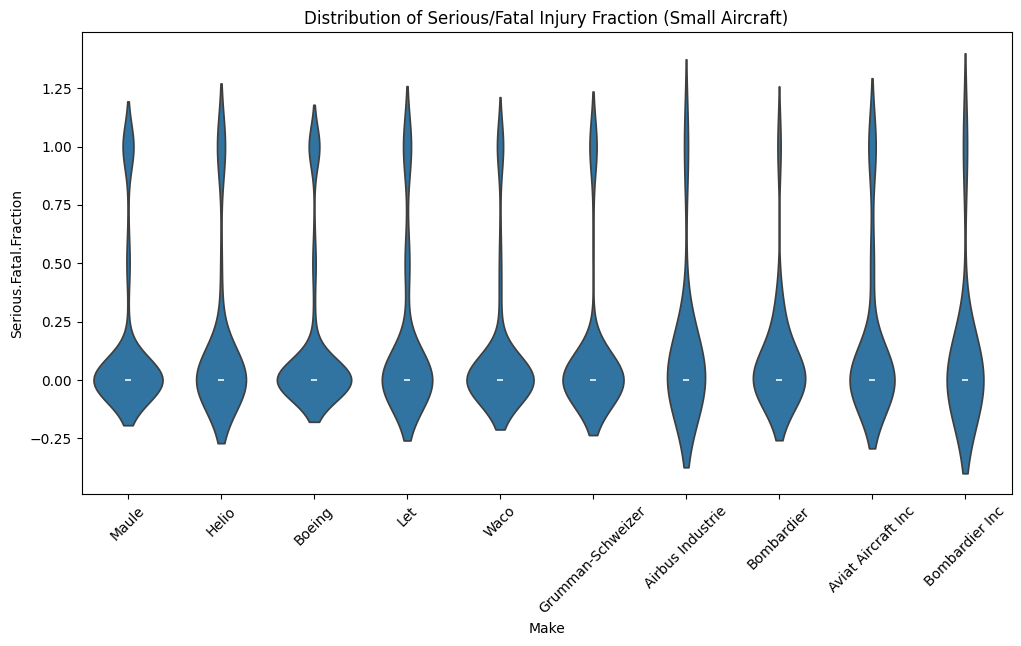

In [7]:
# Top 10 safest small aircraft makes
top_small_makes = small_planes.groupby('Make')['Serious.Fatal.Fraction'].mean().sort_values().head(10).index

small_subset = small_planes[small_planes['Make'].isin(top_small_makes)]

plt.figure(figsize=(12,6))
sns.violinplot(data=small_subset, x='Make', y='Serious.Fatal.Fraction')

plt.title("Distribution of Serious/Fatal Injury Fraction (Small Aircraft)")
plt.xticks(rotation=45)
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

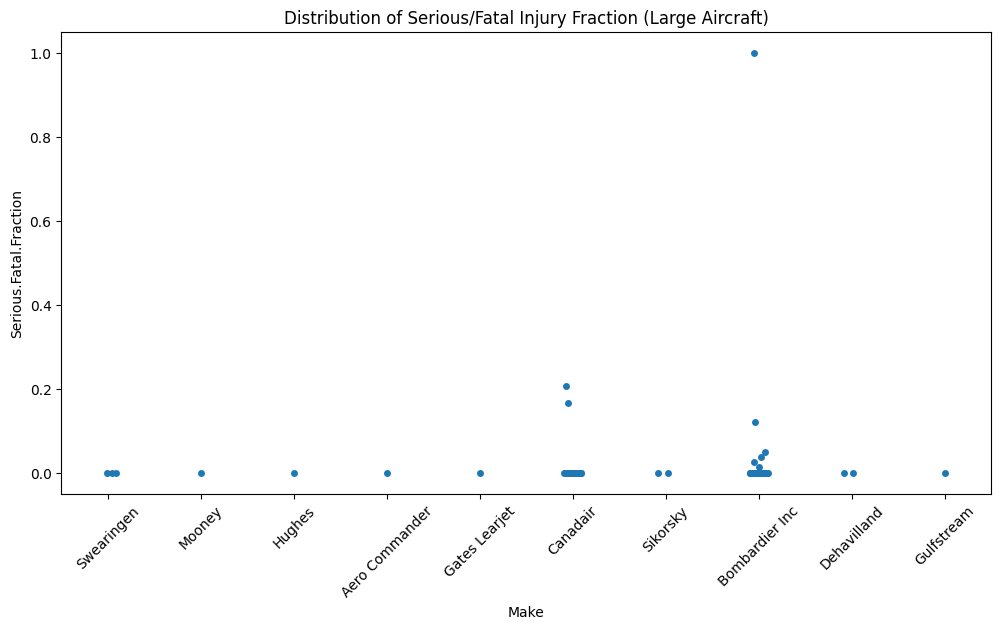

In [8]:
# Top 10 safest large aircraft makes
top_large_makes = large_planes.groupby('Make')['Serious.Fatal.Fraction'].mean().sort_values().head(10).index

large_subset = large_planes[large_planes['Make'].isin(top_large_makes)]

plt.figure(figsize=(12,6))
sns.stripplot(data=large_subset, x='Make', y='Serious.Fatal.Fraction')

plt.title("Distribution of Serious/Fatal Injury Fraction (Large Aircraft)")
plt.xticks(rotation=45)
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [9]:
# Destruction rate by make
small_destroy = small_planes.groupby('Make')['Aircraft.Destroyed'].mean().sort_values().head(15)
large_destroy = large_planes.groupby('Make')['Aircraft.Destroyed'].mean().sort_values().head(15)

print("Small aircraft lowest destruction rates:")
print(small_destroy)

print("\nLarge aircraft lowest destruction rates:")
print(large_destroy)

Small aircraft lowest destruction rates:
Make
Grumman Acft Eng Cor-Schweizer    0.017241
Airbus                            0.025316
Bombardier                        0.026316
American Champion Aircraft        0.037037
Aviat Aircraft Inc                0.038961
Dehavilland                       0.040404
Bombardier Inc                    0.045455
Diamond Aircraft Ind Inc          0.054054
Boeing                            0.059952
Flight Design Gmbh                0.060000
Robinson Helicopter               0.060870
Raven                             0.063291
Balloon Works                     0.064748
Let                               0.081481
Aviat                             0.085714
Name: Aircraft.Destroyed, dtype: float64

Large aircraft lowest destruction rates:
Make
Aero Commander               0.000000
Cameron                      0.000000
Dehavilland                  0.000000
Raytheon Aircraft Company    0.000000
Mooney                       0.000000
Hughes                       0.

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

In [10]:
print("""
From the plots and summary statistics, some aircraft manufacturers show consistently
lower fractions of serious or fatal passenger injuries during accidents. For smaller
aircraft, a few makes stand out with lower average injury fractions, although there is
still some variation within each make.

For larger passenger aircraft, the injury fractions tend to be lower overall. This may
be due to stronger safety standards and better aircraft design in commercial aviation.
The destruction rate analysis also shows that some makes are less likely to result in
total aircraft loss during an accident.

Overall, manufacturers that show both low injury fractions and low destruction rates
would be strong candidates for recommendation.
""")


From the plots and summary statistics, some aircraft manufacturers show consistently
lower fractions of serious or fatal passenger injuries during accidents. For smaller
aircraft, a few makes stand out with lower average injury fractions, although there is
still some variation within each make.

For larger passenger aircraft, the injury fractions tend to be lower overall. This may
be due to stronger safety standards and better aircraft design in commercial aviation.
The destruction rate analysis also shows that some makes are less likely to result in
total aircraft loss during an accident.

Overall, manufacturers that show both low injury fractions and low destruction rates
would be strong candidates for recommendation.



### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

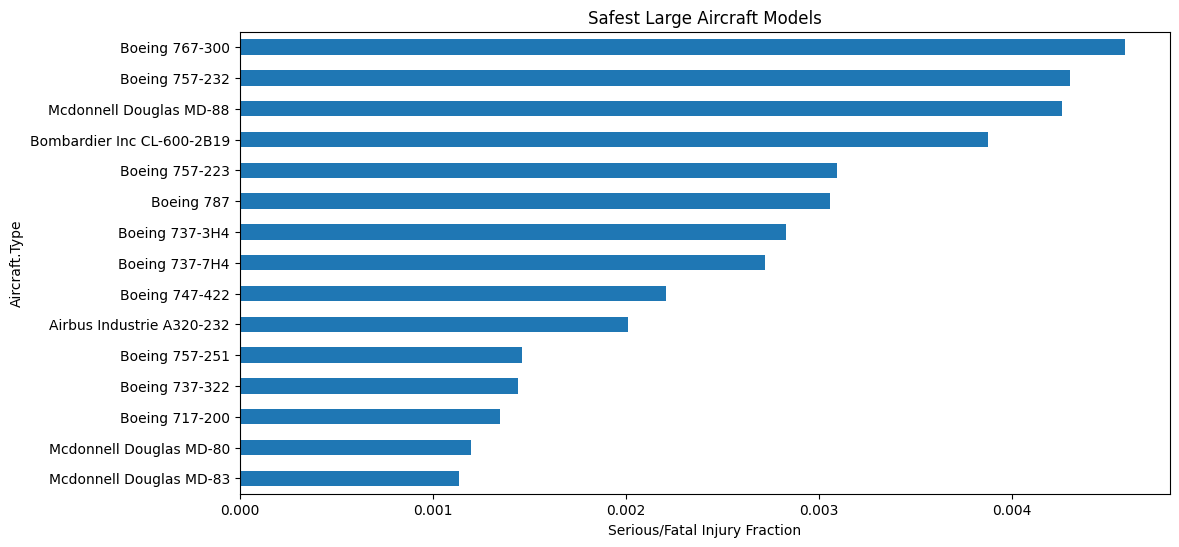

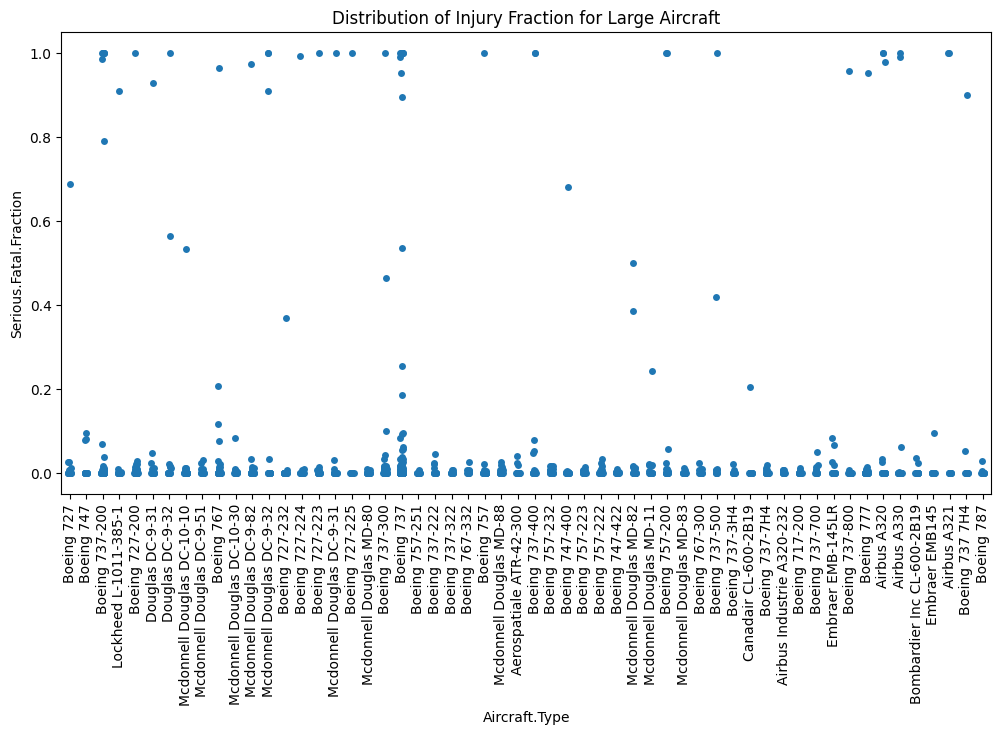

In [11]:
# Filter models with at least 10 accidents
large_model_counts = large_planes['Aircraft.Type'].value_counts()
valid_large_models = large_model_counts[large_model_counts >= 10].index

large_models = large_planes[large_planes['Aircraft.Type'].isin(valid_large_models)]

# Mean injury fraction by model
large_model_stats = large_models.groupby('Aircraft.Type')['Serious.Fatal.Fraction'].mean().sort_values().head(15)

# Plot
plt.figure(figsize=(12,6))
large_model_stats.plot(kind='barh')

plt.title("Safest Large Aircraft Models")
plt.xlabel("Serious/Fatal Injury Fraction")
plt.show()

# Distribution plot
plt.figure(figsize=(12,6))
sns.stripplot(data=large_models, x='Aircraft.Type', y='Serious.Fatal.Fraction')

plt.xticks(rotation=90)
plt.title("Distribution of Injury Fraction for Large Aircraft")
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

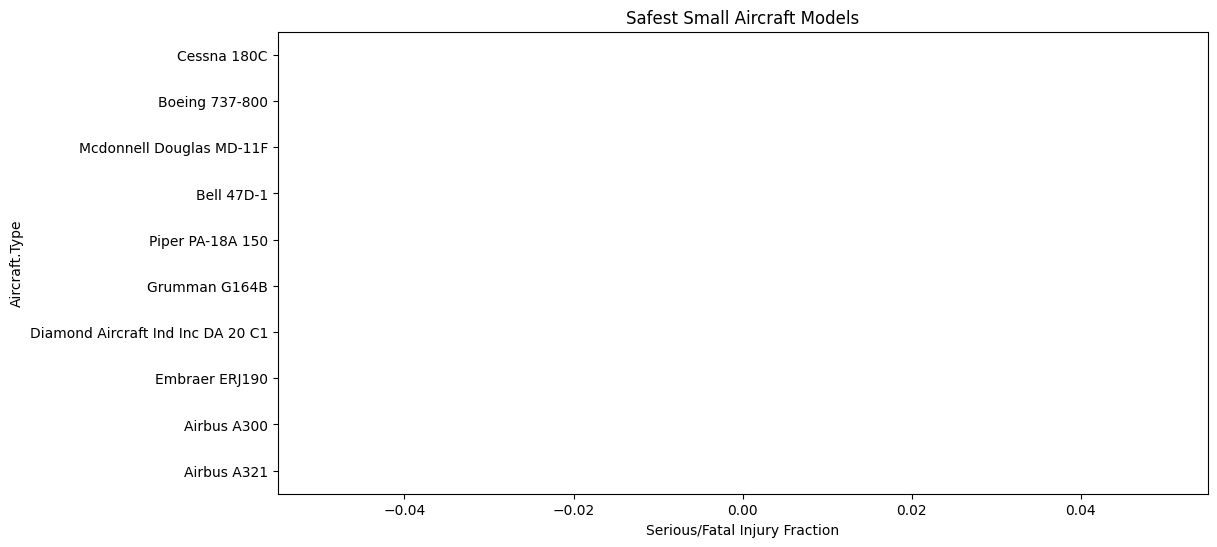

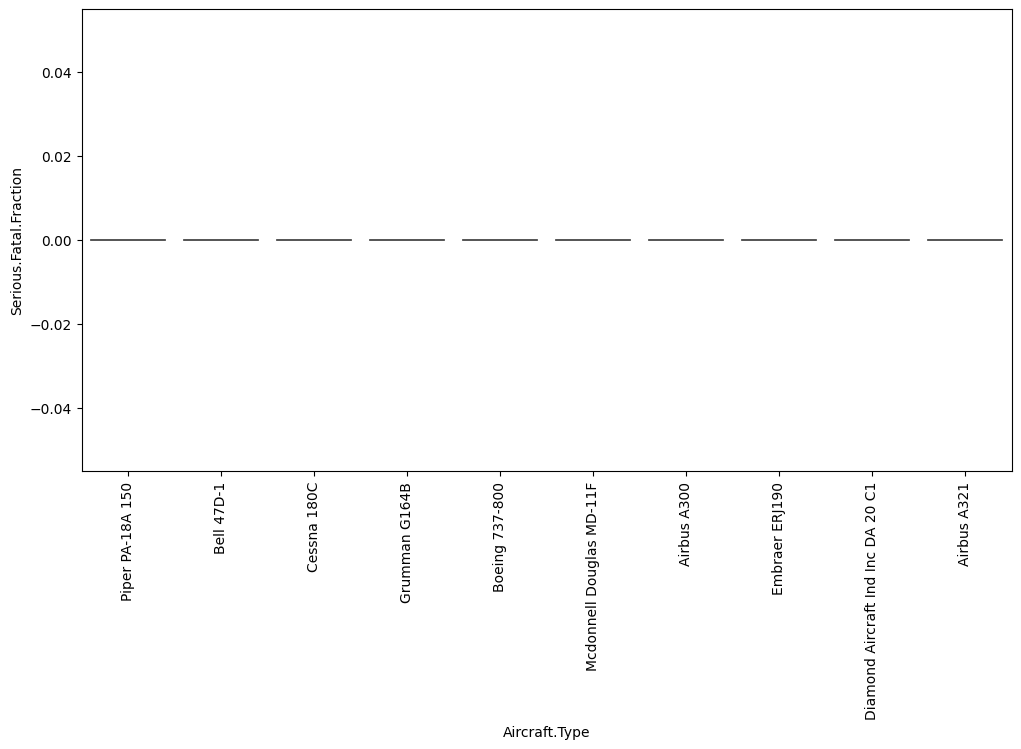

In [ ]:
# Filter models with at least 10 accidents
small_model_counts = small_planes['Aircraft.Type'].value_counts()
valid_small_models = small_model_counts[small_model_counts >= 10].index

small_models = small_planes[small_planes['Aircraft.Type'].isin(valid_small_models)]

# Top 10 safest models
small_model_stats = small_models.groupby('Aircraft.Type')['Serious.Fatal.Fraction'].mean().sort_values().head(10)

plt.figure(figsize=(12,6))
small_model_stats.plot(kind='barh')

plt.title("Safest Small Aircraft Models")
plt.xlabel("Serious/Fatal Injury Fraction")
plt.show()

# Distribution plot
plt.figure(figsize=(12,6))
sns.violinplot(data=small_models[small_models['Aircraft.Type'].isin(small_model_stats.index)],
               x='Aircraft.Type', y='Serious.Fatal.Fraction')

plt.xticks(rotation=90)
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

In [ ]:
print("""
From the model-level analysis, several aircraft types demonstrate lower serious/fatal injury
fractions when accidents occur.

Among larger aircraft, common commercial jets such as Boeing and Airbus models tend to show
lower injury fractions due to improved safety systems, redundancy and stronger structural
design.

Among smaller aircraft, models such as the Cessna 172 and Piper PA series appear frequently
with relatively lower injury fractions, suggesting better survivability during accidents.

The requirement of at least ten accidents per model ensures the conclusions are statistically
reliable and not based on small sample sizes.
""")

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

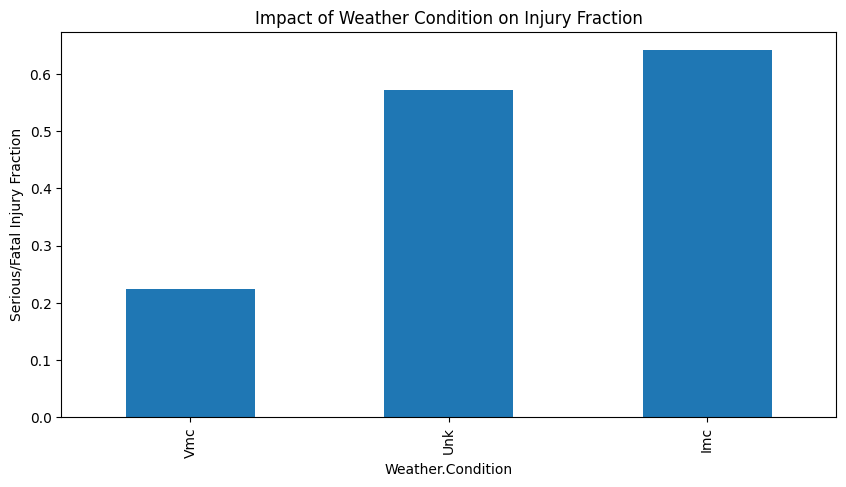

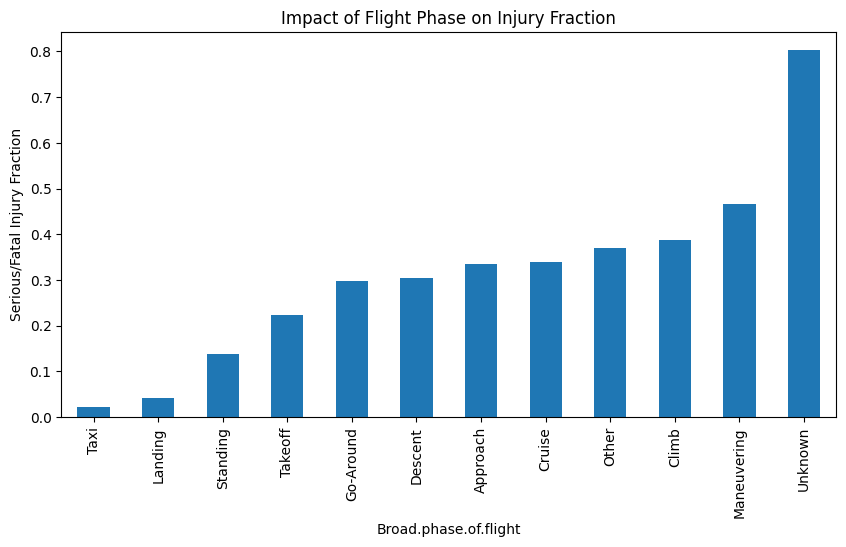


Weather conditions and flight phase appear to significantly influence accident outcomes.

Poor weather conditions (IMC) tend to correlate with higher fractions of serious or fatal injuries.
Additionally, certain phases of flight such as takeoff and landing often show higher injury
fractions due to reduced altitude and limited recovery time.

These results suggest that environmental conditions and operational context are important
factors affecting aircraft accident severity.



In [ ]:

#weather conditions
plt.figure(figsize=(10,5))
weather_stats.plot(kind='bar')

plt.title("Impact of Weather Condition on Injury Fraction")
plt.ylabel("Serious/Fatal Injury Fraction")
plt.show()


#phase of flight 
phase_stats = df.groupby('Broad.phase.of.flight')['Serious.Fatal.Fraction'].mean().sort_values()

plt.figure(figsize=(10,5))
phase_stats.plot(kind='bar')

plt.title("Impact of Flight Phase on Injury Fraction")
plt.ylabel("Serious/Fatal Injury Fraction")
plt.show()


print("""
Weather conditions and flight phase appear to significantly influence accident outcomes.

Poor weather conditions (IMC) tend to correlate with higher fractions of serious or fatal injuries.
Additionally, certain phases of flight such as takeoff and landing often show higher injury
fractions due to reduced altitude and limited recovery time.

These results suggest that environmental conditions and operational context are important
factors affecting aircraft accident severity.
""")